# Assessing non-Markovianity

**Aim:**
Test whether resting-state EEG microstate sequences are consistent with a Markov chain structure, using the classical likelihood-ratio test battery of Kullback (1962).

**Note:** As we are inspecting the autocorrelation structure of microstate sequences in detail, working towards topics like persistence, long-range correlations, Hurst exponents etc., we are now turning towards **_continuous microstate sequences_**, i.e. time series that contain the microstate label at each time stamp, including duplicates and all.

**Procedure:**
1. Conduct low-order Markovianity tests
2. Check Markovianity using the approach via exponential lifetime distributions
3. Visualize autocorrelations of continuous microstate sequence and compare to predictions if the sequence was Markovian.

**Data**: MPILMBB EEG microstate sequences

**Statistics**: All p-values are FDR-corrected (Benjamini-Hochberg, `mstsa.multiple_comparisons`) across the n=201 subjects (or subject x state pairs) within each test family, and we report the proportion of subjects for which the corresponding null hypothesis is rejected at alpha=0.05.


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import mstsa

print(mstsa.__version__)

0.4.2


In [2]:
data_path = "../data/mpilmbb"

# Smoothing (pre-processing) condition to analyze: one of 'b1', 'b3', 'b9', 'ip', or
# 'all' to pool every condition together.
smoothing = 'b1'
_SMOOTHING_CHOICES = ('b1', 'b3', 'b9', 'ip', 'all')
if smoothing not in _SMOOTHING_CHOICES:
    raise ValueError(f"smoothing must be one of {_SMOOTHING_CHOICES}, got {smoothing!r}")

pattern = "*_EC_*.npy" if smoothing == 'all' else f"*_EC_ms_{smoothing}_K4_*.npy"
files = sorted(glob.glob(f"{data_path}/{pattern}"))
print(f"smoothing={smoothing!r}: {len(files)} EC files")

alpha = 0.05
K_states = 4  # MPILMBB microstate maps A-D

smoothing='b1': 201 EC files


## Markov order (0th / 1st / 2nd)

`test_markov0` tests the i.i.d. (order-0) null; `test_markov1` tests whether a
first-order model is *sufficient* (i.e. whether two-step transitions are consistent
with one-step transitions); `test_markov2` tests whether a *second*-order model is
needed beyond first order. All three are likelihood-ratio (G) tests against a
chi-squared null (Kullback, 1962).

In [3]:
cache_dir = "../data/cache/nonmarkovianity"
os.makedirs(cache_dir, exist_ok=True)
cache_file_order = os.path.join(cache_dir, f"order_tests_{smoothing}.npz")

if os.path.exists(cache_file_order):
    d = np.load(cache_file_order)
    p_markov0 = d['p_markov0']
    p_markov1 = d['p_markov1']
    p_markov2 = d['p_markov2']
    print(f"loaded cached Markov order test results from {cache_file_order}")
else:
    p_markov0 = np.zeros(len(files))
    p_markov1 = np.zeros(len(files))
    p_markov2 = np.zeros(len(files))

    for i, f in enumerate(files):
        x = np.load(f)
        K = len(set(x))
        p_markov0[i] = mstsa.test_markov0(x, K)
        p_markov1[i] = mstsa.test_markov1(x, K)
        p_markov2[i] = mstsa.test_markov2(x, K)
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file_order, 
             p_markov0=p_markov0, 
             p_markov1=p_markov1, 
             p_markov2=p_markov2)

p_markov0_fdr = mstsa.multiple_comparisons(p_markov0, method='fdr_bh')
p_markov1_fdr = mstsa.multiple_comparisons(p_markov1, method='fdr_bh')
p_markov2_fdr = mstsa.multiple_comparisons(p_markov2, method='fdr_bh')

frac_reject0 = np.mean(p_markov0_fdr < alpha)
frac_reject1 = np.mean(p_markov1_fdr < alpha)
frac_reject2 = np.mean(p_markov2_fdr < alpha)
print(f"reject i.i.d. (order 0):    {frac_reject0 * 100:5.1f}% of subjects (FDR)")
print(f"reject order-1 sufficiency: {frac_reject1 * 100:5.1f}% of subjects (FDR)")
print(f"reject order-2 sufficiency: {frac_reject2 * 100:5.1f}% of subjects (FDR)")

loaded cached Markov order test results from ../data/cache/nonmarkovianity/order_tests_b1.npz
reject i.i.d. (order 0):    100.0% of subjects (FDR)
reject order-1 sufficiency: 100.0% of subjects (FDR)
reject order-2 sufficiency: 100.0% of subjects (FDR)


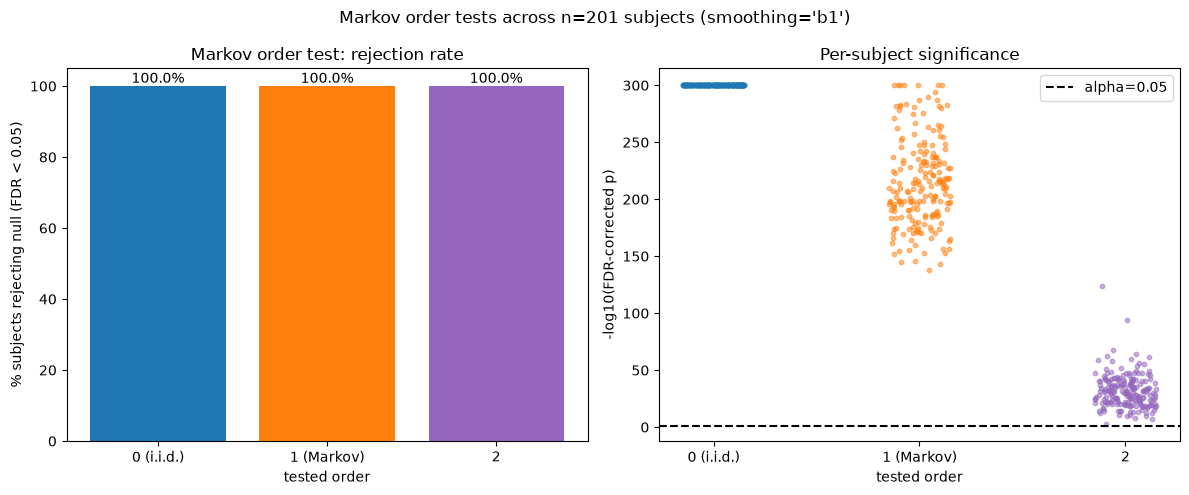

In [4]:
def _neglog10p(p):
    return -np.log10(np.clip(p, 1e-300, 1.0))


order_labels = ['0 (i.i.d.)', '1 (Markov)', '2']
order_fracs = [frac_reject0 * 100, frac_reject1 * 100, frac_reject2 * 100]
order_colors = ['tab:blue', 'tab:orange', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(order_labels, order_fracs, color=order_colors)
axes[0].set_ylim(0, 105)
axes[0].set_xlabel('tested order')
axes[0].set_ylabel('% subjects rejecting null (FDR < 0.05)')
axes[0].set_title('Markov order test: rejection rate')
for lab, frac in zip(order_labels, order_fracs):
    axes[0].annotate(f"{frac:.1f}%", (lab, frac), ha='center', va='bottom')

rng = np.random.default_rng(0)
for j, (p_fdr, color) in enumerate(zip([p_markov0_fdr, 
                                        p_markov1_fdr, 
                                        p_markov2_fdr], order_colors)):
    y = _neglog10p(p_fdr)
    jitter = rng.uniform(-0.15, 0.15, size=len(y))
    axes[1].scatter(np.full(len(y), j) + jitter, y, s=10, color=color, alpha=0.5)
axes[1].axhline(-np.log10(alpha), color='k', ls='--', label=f'alpha={alpha}')
axes[1].set_xticks(range(len(order_labels)))
axes[1].set_xticklabels(order_labels)
axes[1].set_xlabel('tested order')
axes[1].set_ylabel('-log10(FDR-corrected p)')
axes[1].set_title('Per-subject significance')
axes[1].legend()

fig.suptitle(f'Markov order tests across n={len(files)} subjects '
             f'(smoothing={smoothing!r})')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/02_nonmarkovianity_order_tests.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## Sojourn-time geometricity

A first-order (memoryless) Markov chain implies that the sojourn time in each state follows a geometric distribution. `mstsa.test_geometric_seq` compares the observed dwell-time histogram of each microstate against a fitted geometric distribution.

In [5]:
cache_file_geom = os.path.join(cache_dir, f"geometricity_{smoothing}.npz")

if os.path.exists(cache_file_geom):
    p_geom = np.load(cache_file_geom)['p_geom']
    print(f"loaded cached sojourn-time geometricity results from {cache_file_geom}")
else:
    p_geom = np.full((len(files), K_states), np.nan)

    for i, f in enumerate(files):
        x = np.load(f)
        K = len(set(x))
        p_geom[i, :K] = mstsa.test_geometric_seq(x, K, verbose=False)
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file_geom, p_geom=p_geom)

valid = np.isfinite(p_geom)
p_geom_fdr = np.full_like(p_geom, np.nan)
p_geom_fdr[valid] = mstsa.multiple_comparisons(p_geom[valid], method='fdr_bh')

frac_reject_geom = np.nanmean(p_geom_fdr < alpha, axis=0)
for k in range(K_states):
    print(f"state {k}: {frac_reject_geom[k] * 100:5.1f}% of subjects reject geometric "
          f"dwell times (FDR-corrected)")

loaded cached sojourn-time geometricity results from ../data/cache/nonmarkovianity/geometricity_b1.npz
state 0: 100.0% of subjects reject geometric dwell times (FDR-corrected)
state 1: 100.0% of subjects reject geometric dwell times (FDR-corrected)
state 2: 100.0% of subjects reject geometric dwell times (FDR-corrected)
state 3: 100.0% of subjects reject geometric dwell times (FDR-corrected)


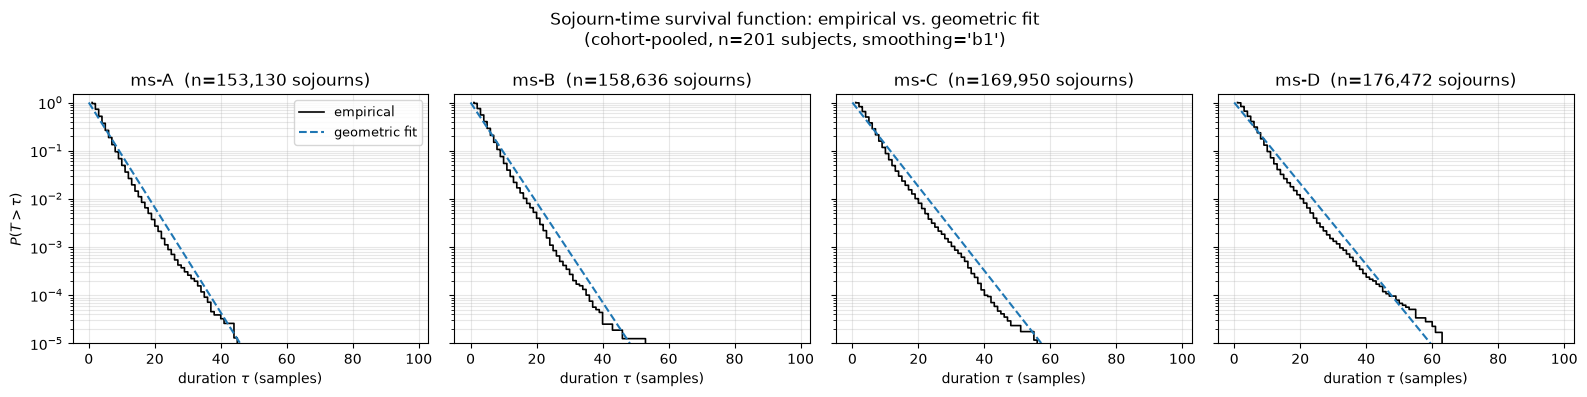

In [6]:
geom_labels = ['A', 'B', 'C', 'D'][:K_states]

# pool sojourn times across the full cohort, separately per microstate class,
# and compare the empirical survival function (CCDF) against the geometric
# fit implied by the pooled mean duration -- far more informative than a
# reject/not-reject bar chart, since it shows *where* (which durations) the
# geometric model breaks down, not just whether it does
tau_pooled = [[] for _ in range(K_states)]
for f in files:
    x = np.load(f)
    K = len(set(x))
    tau_list = mstsa.sojourn_times_unordered(x, K)
    for k in range(K):
        tau_pooled[k].extend(tau_list[k])
tau_pooled = [np.asarray(t) for t in tau_pooled]

fig, axes = plt.subplots(1, K_states, figsize=(4 * K_states, 4), sharex=True, sharey=True)
for k in range(K_states):
    tau = np.sort(tau_pooled[k])
    n = len(tau)
    # empirical CCDF: P(T > tau), evaluated just past each observed duration
    ccdf_emp = 1.0 - np.arange(1, n + 1) / n

    # geometric fit: same p = (mu-1)/mu reconstruction used by
    # mstsa.test_geometric_dist; survival function is P(T > t) = p^t
    mu = tau.mean()
    p_geo = (mu - 1) / mu
    t_grid = np.arange(0, tau.max() + 1)
    ccdf_exp = p_geo ** t_grid

    ax = axes[k]
    ax.step(tau, np.maximum(ccdf_emp, 1e-6), where='post', color='k', lw=1.2,
             label='empirical')
    ax.plot(t_grid, ccdf_exp, color='tab:blue', lw=1.5, ls='--', label='geometric fit')
    ax.set_yscale('log')
    ax.set_xlabel(r'duration $\tau$ (samples)')
    ax.set_title(f'ms-{geom_labels[k]}  (n={n:,} sojourns)')
    ax.set_ylim(1e-5, 1.5)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel(r'$P(T > \tau)$')
axes[0].legend(fontsize=9)
fig.suptitle('Sojourn-time survival function: empirical vs. geometric fit\n'
             f'(cohort-pooled, n={len(files)} subjects, smoothing={smoothing!r})')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/02_nonmarkovianity_geometric_ccdf.png', dpi=150, bbox_inches='tight')
plt.show()


## Auto- and partial auto-information functions (AIF / PAIF)

Markov models show a mixed exponential decay of time-lagged autocorrelations. Partial autocorrelations drop to zero beyond the actual time lag across which the generating process acts.  
Since microstate sequences are symbolic sequences, i.e. the time series is over a nominal (categorical) variable, we use time-lagged mutual-information `AIF(k) = I(X_t; X_{t+k})` where `X_t` is the microstate sequence. In analogy of ACF/PACF, we call them AIF/PAIF, (partial) autoinformation function.

For example, a first-order Markov process should only have one non-zero PAIF coefficient at time lag 1.

**Computation:** 
- The mstsa package implements these functions as `mstsa.aif` and `mstsa.paif`
- To compare to the Markovian case, we construct confidence intervals from surrogate Markov processes with the same parameters `p` and `T` as the underlying empirical microstate sequence using `mstsa.mc_sample_path`
- **Note:** The time lags `k=0,1` for PAIF are omitted as they are identical to the Markov surrogate model by construction.

In [7]:
kmax_aif = 100
kmax_paif = 7
n_subset = 30
n_surr = 5

cache_dir = "../data/cache/nonmarkovianity_aif"
cache_file = os.path.join(cache_dir, f"aif_paif_{smoothing}_n{n_subset}_s{n_surr}.npz")
os.makedirs(cache_dir, exist_ok=True)

if os.path.exists(cache_file):
    d = np.load(cache_file)
    aif_real, aif_surr = d['aif_real'], d['aif_surr']
    paif_real, paif_surr = d['paif_real'], d['paif_surr']
    print(f"loaded cached AIF/PAIF results from {cache_file}")
else:
    rng = np.random.default_rng(0)
    subset_idx = rng.choice(len(files), size=n_subset, replace=False)
    subset_files = [files[i] for i in subset_idx]

    aif_real = np.zeros((n_subset, kmax_aif))
    aif_surr = np.zeros((n_subset, n_surr, kmax_aif))

    paif_real = np.zeros((n_subset, kmax_paif))
    paif_surr = np.zeros((n_subset, n_surr, kmax_paif))

    for i, f in enumerate(subset_files):
        x = np.load(f)
        K = len(set(x))

        aif_real[i] = mstsa.aif(x, K, kmax=kmax_aif)
        paif_real[i] = mstsa.paif(x, K, kmax=kmax_paif)

        T = mstsa.tpm_cond(x, K)
        p = mstsa.pmf(x, K)
        for s in range(n_surr):
            surr = mstsa.mc_sample_path(T=T, n=len(x), p=p)
            aif_surr[i, s] = mstsa.aif(surr, K, kmax=kmax_aif)
            paif_surr[i, s] = mstsa.paif(surr, K, kmax=kmax_paif)

        print(f"[{i+1}/{n_subset}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file, aif_real=aif_real, aif_surr=aif_surr,
              paif_real=paif_real, paif_surr=paif_surr)

aif_real_mean = aif_real.mean(axis=0)
aif_surr_pool = aif_surr.reshape(-1, kmax_aif)  # (n_subset * n_surr, kmax_aif)
aif_ci_lo, aif_ci_hi = np.percentile(aif_surr_pool, [2.5, 97.5], axis=0)

paif_real_mean = paif_real.mean(axis=0)
paif_surr_pool = paif_surr.reshape(-1, kmax_paif)
paif_ci_lo, paif_ci_hi = np.percentile(paif_surr_pool, [2.5, 97.5], axis=0)

lags_aif = np.arange(kmax_aif)
lags_paif = np.arange(kmax_paif)

n_out_aif = np.sum((aif_real_mean < aif_ci_lo) | (aif_real_mean > aif_ci_hi))
n_out_paif = np.sum((paif_real_mean < paif_ci_lo) | (paif_real_mean > paif_ci_hi))
print(f"AIF:  {n_out_aif}/{kmax_aif} lags where the group-mean real AIF falls outside "
      f"the surrogate 95% CI")
print(f"PAIF: {n_out_paif}/{kmax_paif} lags where the group-mean real PAIF falls "
      f"outside the surrogate 95% CI")

loaded cached AIF/PAIF results from ../data/cache/nonmarkovianity_aif/aif_paif_b1_n30_s5.npz
AIF:  43/100 lags where the group-mean real AIF falls outside the surrogate 95% CI
PAIF: 5/7 lags where the group-mean real PAIF falls outside the surrogate 95% CI


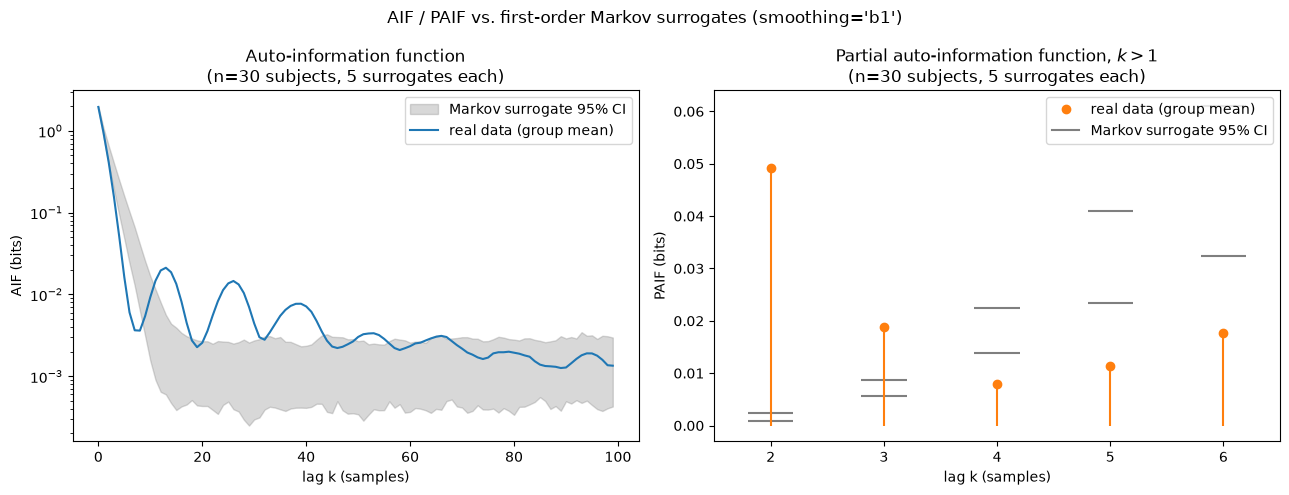

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].fill_between(lags_aif, aif_ci_lo, aif_ci_hi, color='tab:gray', alpha=0.3,
                      label='Markov surrogate 95% CI')
axes[0].plot(lags_aif, aif_real_mean, color='tab:blue', lw=1.5, label='real data (group mean)')
axes[0].set_yscale('log')
axes[0].set_xlabel('lag k (samples)')
axes[0].set_ylabel('AIF (bits)')
axes[0].set_title(f'Auto-information function\n(n={n_subset} subjects, {n_surr} surrogates each)')
axes[0].legend()

# k=0, 1 are identical to the first-order Markov surrogate by construction
# (PAIF at those lags reduces to normalization / the AIF(1) term the
# surrogate is built from), so only k>1 is informative -- restrict the plot
# to that range.
paif_mask = lags_paif > 1
lags_paif_plot = lags_paif[paif_mask]

markerline, stemlines, baseline = axes[1].stem(lags_paif_plot, paif_real_mean[paif_mask], basefmt=' ')
plt.setp(markerline, color='tab:orange', markersize=6, zorder=3)
plt.setp(stemlines, color='tab:orange', linewidth=1.5, zorder=3)
cap_halfwidth = 0.2
for k in lags_paif_plot:
    axes[1].hlines([paif_ci_lo[k], paif_ci_hi[k]], k - cap_halfwidth, k + cap_halfwidth,
                    color='tab:gray', linewidth=1.5, zorder=2)
axes[1].set_xlabel('lag k (samples)')
axes[1].set_ylabel('PAIF (bits)')
axes[1].set_xticks(lags_paif_plot)
axes[1].set_xlim(lags_paif_plot[0] - 0.5, lags_paif_plot[-1] + 0.5)
axes[1].set_title(f'Partial auto-information function, $k>1$\n(n={n_subset} subjects, {n_surr} surrogates each)')
axes[1].legend(handles=[markerline, plt.Line2D([0], [0], color='tab:gray', lw=1.5)],
               labels=['real data (group mean)', 'Markov surrogate 95% CI'])

fig.suptitle(f'AIF / PAIF vs. first-order Markov surrogates (smoothing={smoothing!r})')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/02_nonmarkovianity_aif_paif.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusions

1. Continuous microstate sequences do not fulfill low-order Markov laws with virtually 100% certainty.
2. Visually, durations (=lifetimes, sojourn times) are not far from a geometric distribution, but statistically clearly rejected. 
    - Note that a geometric (discrete version of exponential) lifetime distribution is **_equivalent_** to the Markov property.
    - We will return to sojourn time distributions in `05_Hurst_phenomenon.ipynb`
3. Extending the scope across a wider range of time lags, microsate sequences show a clear non-Markovian signature, in particular periodicity in the AIF.
4. Overall, this encourages further investigations into the correlation and memory structure of microstate sequences.

**References:**
- von Wegner, F., Tagliazucchi, E., & Laufs, H. (2017). Information-theoretical analysis of resting state EEG microstate sequences - non-Markovianity, non-stationarity and periodicities. *NeuroImage*, 158, 99-111.
- von Wegner, F. (2018). Partial autoinformation to characterize symbolic sequences. *Frontiers in Physiology*, 9, 1382.